# Statistical Analysis
## Customer Behavioral Analysis and Churn Prediction

### Objective

This notebook performs statistical analysis on the cleaned customer churn dataset.

It answers three main research questions:

**RQ1 — Numerical variables**  
Are numerical customer characteristics significantly different between Active and Churned customers?

**RQ2 — Categorical variables**  
Are categorical customer characteristics associated with Churn?

**RQ3 — Effect size**  
Which differences or associations are not only statistically significant, but also have a measurable effect size?

### Target variable

- `Churned = 0`: Active customer
- `Churned = 1`: Churned customer

### Important interpretation rule

Statistical significance does **not** prove causation.  
The results describe differences or associations observed in this dataset.

## Notebook workflow

```text
Load Clean Dataset
        ↓
Data Validation
        ↓
Descriptive Statistics
        ↓
Distribution / Assumption Checks
        ↓
Numerical Statistical Tests
        ↓
Categorical Statistical Tests
        ↓
Effect Size
        ↓
Benjamini-Hochberg FDR Correction
        ↓
Visualization
        ↓
Final Statistical Summary
        ↓
Business Interpretation
        ↓
CSV Outputs for Feature Engineering / ML
```

## 1. Setup

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    ttest_ind,
    mannwhitneyu,
    chi2_contingency,
    fisher_exact
)

from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
ALPHA = 0.05

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

The notebook uses the already-cleaned dataset.

If your project has a different folder structure, only change `DATA_PATH`.

In [3]:
# ============================================================
# PATH CONFIGURATION
# ============================================================

DATA_PATH = "D:/Desktop/Projects/customer-churn-analytics/data/processed/customer_churn_clean.csv"

OUTPUT_DIR = "D:/Desktop/Projects/customer-churn-analytics/reports/statistical_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Data path:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)

Data path: D:/Desktop/Projects/customer-churn-analytics/data/processed/customer_churn_clean.csv
Output directory: D:/Desktop/Projects/customer-churn-analytics/reports/statistical_analysis


In [4]:
# ============================================================
# LOAD DATA
# ============================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Please update DATA_PATH to the location of customer_churn_clean.csv."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 50,000
Columns: 25


In [5]:
display(df.head())

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0000,Male,France,Marseille,2.9000,14.0000,27.4000,6.0000,50.6000,3.0000,9.0000,94.7200,34.0000,46.4000,2.0000,17.9000,9.0000,4.0000,16.3000,20.8000,1.0000,953.3300,2278.0000,0,Q1
1,36.0000,Male,UK,Manchester,1.6000,15.0000,42.7000,10.3000,37.7000,1.0000,19.5000,82.4500,71.0000,57.9600,9.2000,42.8000,7.0000,3.0000,27.6000,23.3000,3.0000,1067.4700,3028.0000,0,Q4
2,45.0000,Female,Canada,Vancouver,2.9000,10.0000,24.8000,1.6000,70.9000,1.0000,9.1000,165.5200,11.0000,12.2400,11.5000,0.0000,4.0000,1.0000,27.6000,8.8000,2.0000,1289.7500,2317.0000,0,Q4
3,56.0000,Female,USA,New York,2.6000,10.0000,38.4000,14.8000,41.7000,9.0000,15.0000,147.3300,47.0000,44.1000,5.4000,41.4000,2.0000,5.0000,85.9000,31.0000,3.0000,2340.9200,2674.0000,0,Q1
4,35.0000,Male,India,Delhi,3.1000,29.0000,51.4000,8.4000,19.1000,9.0000,32.5000,141.3000,73.0000,25.2000,5.5000,37.9000,1.0000,11.0000,83.0000,50.4000,4.0000,3041.2900,5354.0000,0,Q4


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data_Type"))

Column names:
['Age', 'Gender', 'Country', 'City', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned', 'Signup_Quarter']

Data types:


,Data_Type
Age,float64
Gender,str
Country,str
City,str
Membership_Years,float64
Login_Frequency,float64
Session_Duration_Avg,float64
Pages_Per_Session,float64
Cart_Abandonment_Rate,float64
Wishlist_Items,float64


## 3. Data Validation

The dataset must contain a valid binary target:

```text
Churned ∈ {0, 1}
```

This notebook does not redo the complete data-cleaning process. It validates that the cleaned input is suitable for statistical analysis.

In [7]:
# ============================================================
# BASIC VALIDATION
# ============================================================

print(f"Shape: {df.shape}")

print("\nMissing values:")
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing_Count")
)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (50000, 25)

Missing values:


,Missing_Count
Age,0
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,0
Pages_Per_Session,0
Cart_Abandonment_Rate,0
Wishlist_Items,0



Duplicate rows: 0


In [8]:
# ============================================================
# TARGET VALIDATION
# ============================================================

TARGET = "Churned"

if TARGET not in df.columns:
    raise ValueError("Required target column 'Churned' does not exist.")

if df[TARGET].isna().any():
    raise ValueError("Target column 'Churned' contains missing values.")

target_values = set(df[TARGET].unique())

print("Unique target values:", sorted(target_values))

if not target_values.issubset({0, 1}):
    raise ValueError(
        f"Invalid target values found: {target_values}. "
        "Churned must contain only 0 and 1."
    )

print("Target validation passed.")

Unique target values: [np.int64(0), np.int64(1)]
Target validation passed.


In [9]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

target_counts = df[TARGET].value_counts().sort_index()
target_percent = df[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Customer_Count": target_counts,
    "Percentage": target_percent
})

target_summary.index = [
    "Active (0)" if idx == 0 else "Churned (1)"
    for idx in target_summary.index
]

display(target_summary)

print(f"\nOverall churn rate: {df[TARGET].mean() * 100:.2f}%")

,Customer_Count,Percentage
Active (0),35550,71.1000
Churned (1),14450,28.9000



Overall churn rate: 28.90%


## 4. Define Analysis Variables

The variables follow the dataset's business categories.

### Numerical variables

Customer demographics, engagement, purchase behavior, service activity, and financial metrics.

### Categorical variables

Gender, Country, Signup Quarter, and optional engineered grouping variables if they already exist in the cleaned dataset.

In [10]:
# ============================================================
# FEATURE LISTS
# ============================================================

requested_numerical_features = [
    "Age",
    "Membership_Years",
    "Login_Frequency",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Cart_Abandonment_Rate",
    "Wishlist_Items",
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
    "Returns_Rate",
    "Email_Open_Rate",
    "Customer_Service_Calls",
    "Product_Reviews_Written",
    "Social_Media_Engagement_Score",
    "Mobile_App_Usage",
    "Payment_Method_Diversity",
    "Lifetime_Value",
    "Credit_Balance"
]

requested_categorical_features = [
    "Gender",
    "Country",
    "Signup_Quarter"
]

# Add engineered categorical variables only when they already exist.
optional_categorical_features = [
    "Age_Group",
    "Membership_Group"
]

numerical_features = [
    col for col in requested_numerical_features
    if col in df.columns
]

categorical_features = [
    col for col in requested_categorical_features + optional_categorical_features
    if col in df.columns
]

missing_numerical = [
    col for col in requested_numerical_features
    if col not in df.columns
]

missing_categorical = [
    col for col in requested_categorical_features
    if col not in df.columns
]

print("Numerical features found:")
print(numerical_features)

print("\nCategorical features found:")
print(categorical_features)

if missing_numerical:
    print("\nWARNING — Numerical columns not found:")
    print(missing_numerical)

if missing_categorical:
    print("\nWARNING — Required categorical columns not found:")
    print(missing_categorical)

Numerical features found:
['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']

Categorical features found:
['Gender', 'Country', 'Signup_Quarter']


## 5. Descriptive Statistics

Before hypothesis testing, compare Active and Churned customers using:

- Count
- Mean
- Median
- Standard deviation
- Minimum
- Maximum

This provides context for interpreting the statistical tests.

In [11]:
# ============================================================
# OVERALL DESCRIPTIVE STATISTICS
# ============================================================

display(df[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,50000.0000,37.7754,11.1560,18.0000,30.0000,38.0000,45.0000,75.0000
Membership_Years,50000.0000,2.9840,2.0591,0.1000,1.4000,2.5000,4.0000,10.0000
Login_Frequency,50000.0000,11.6247,7.8107,0.0000,6.0000,11.0000,17.0000,46.0000
Session_Duration_Avg,50000.0000,27.6022,10.4972,1.0000,20.2000,26.8000,34.0000,75.6000
Pages_Per_Session,50000.0000,8.7175,3.6640,1.0000,6.2000,8.4000,11.0000,24.1000
Cart_Abandonment_Rate,50000.0000,57.0430,16.2069,0.0000,46.4000,58.1000,68.7000,100.0000
Wishlist_Items,50000.0000,4.2745,3.0606,0.0000,2.0000,4.0000,6.0000,28.0000
Total_Purchases,50000.0000,13.1262,6.9955,0.0000,8.0000,12.0000,17.0000,128.7000
Average_Order_Value,50000.0000,123.1173,175.5697,26.3800,87.0500,112.9700,144.4400,9666.3792
Days_Since_Last_Purchase,50000.0000,29.2653,28.8660,0.0000,9.0000,21.0000,39.0000,287.0000


In [12]:
# ============================================================
# DESCRIPTIVE STATISTICS BY CHURN
# ============================================================

descriptive_rows = []

for col in numerical_features:
    active = df.loc[df[TARGET] == 0, col].dropna()
    churned = df.loc[df[TARGET] == 1, col].dropna()

    descriptive_rows.append({
        "Variable": col,
        "Active_N": len(active),
        "Churned_N": len(churned),
        "Active_Mean": active.mean(),
        "Churned_Mean": churned.mean(),
        "Active_Median": active.median(),
        "Churned_Median": churned.median(),
        "Active_Std": active.std(),
        "Churned_Std": churned.std(),
        "Active_Min": active.min(),
        "Churned_Min": churned.min(),
        "Active_Max": active.max(),
        "Churned_Max": churned.max()
    })

descriptive_statistics = pd.DataFrame(descriptive_rows)

descriptive_statistics["Mean_Difference"] = (
    descriptive_statistics["Churned_Mean"]
    - descriptive_statistics["Active_Mean"]
)

display(descriptive_statistics)

,Variable,Active_N,Churned_N,Active_Mean,Churned_Mean,Active_Median,Churned_Median,Active_Std,Churned_Std,Active_Min,Churned_Min,Active_Max,Churned_Max,Mean_Difference
0,Age,35550,14450,38.5002,35.9923,38.0000,36.0000,10.7613,11.8861,18.0000,18.0000,75.0000,75.0000,-2.5079
1,Membership_Years,35550,14450,2.9848,2.9820,2.5000,2.5000,2.0640,2.0471,0.1000,0.1000,10.0000,10.0000,-0.0028
2,Login_Frequency,35550,14450,12.6424,9.1208,12.0000,8.0000,7.6886,7.5397,0.0000,0.0000,46.0000,43.0000,-3.5216
3,Session_Duration_Avg,35550,14450,29.0713,23.9880,27.4000,23.6000,10.1732,10.4070,1.0000,1.0000,75.6000,66.3000,-5.0833
4,Pages_Per_Session,35550,14450,9.2425,7.4262,8.7000,7.2000,3.5462,3.6291,1.0000,1.0000,24.1000,23.2000,-1.8163
5,Cart_Abandonment_Rate,35550,14450,54.1554,64.1471,55.5000,66.6000,15.0431,16.7683,0.0000,0.0000,100.0000,100.0000,9.9917
6,Wishlist_Items,35550,14450,4.6444,3.3645,4.0000,3.0000,3.0423,2.9115,0.0000,0.0000,28.0000,19.0000,-1.2799
7,Total_Purchases,35550,14450,13.8440,11.3600,13.0000,10.0000,6.8681,6.9927,0.0000,0.0000,128.7000,124.8000,-2.4840
8,Average_Order_Value,35550,14450,118.3839,134.7625,108.9350,124.3950,171.0654,185.6812,26.3800,26.8700,9666.3792,9487.4280,16.3786
9,Days_Since_Last_Purchase,35550,14450,26.5413,35.9669,21.0000,24.0000,25.8540,34.2877,0.0000,0.0000,276.0000,287.0000,9.4255


## 6. Distribution and Assumption Checks

For large samples, normality tests such as Shapiro-Wilk can become extremely sensitive to very small deviations from normality.

Therefore, this notebook uses:

- Skewness
- Q-Q plots
- Boxplots
- Sample size
- Robustness of Welch's t-test

to support test selection.

The final numerical analysis also calculates Mann-Whitney U as a robust non-parametric comparison.

In [13]:
# ============================================================
# SKEWNESS
# ============================================================

skewness_table = pd.DataFrame({
    "Variable": numerical_features,
    "Skewness": [
        df[col].dropna().skew()
        for col in numerical_features
    ]
})

skewness_table["Absolute_Skewness"] = (
    skewness_table["Skewness"].abs()
)

display(
    skewness_table.sort_values(
        "Absolute_Skewness",
        ascending=False
    )
)

,Variable,Skewness,Absolute_Skewness
8,Average_Order_Value,42.3639,42.3639
11,Returns_Rate,6.1860,6.1860
7,Total_Purchases,2.7273,2.7273
9,Days_Since_Last_Purchase,2.0907,2.0907
18,Lifetime_Value,1.4474,1.4474
14,Product_Reviews_Written,1.1431,1.1431
1,Membership_Years,1.1369,1.1369
6,Wishlist_Items,1.0071,1.0071
17,Payment_Method_Diversity,0.6652,0.6652
15,Social_Media_Engagement_Score,0.5703,0.5703


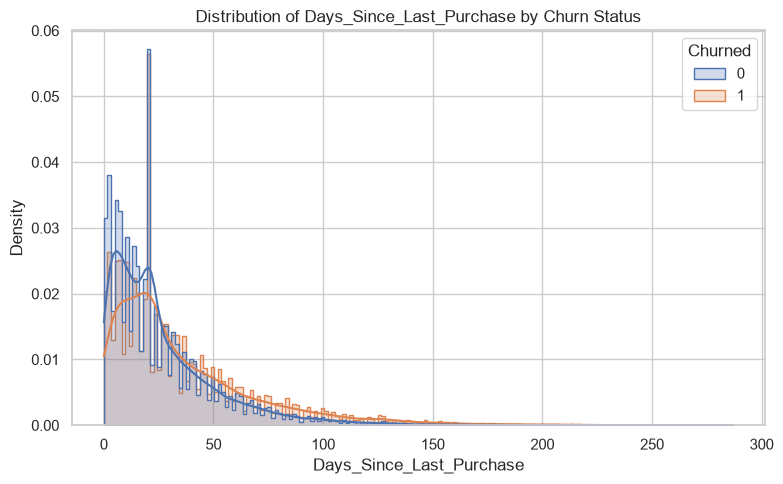

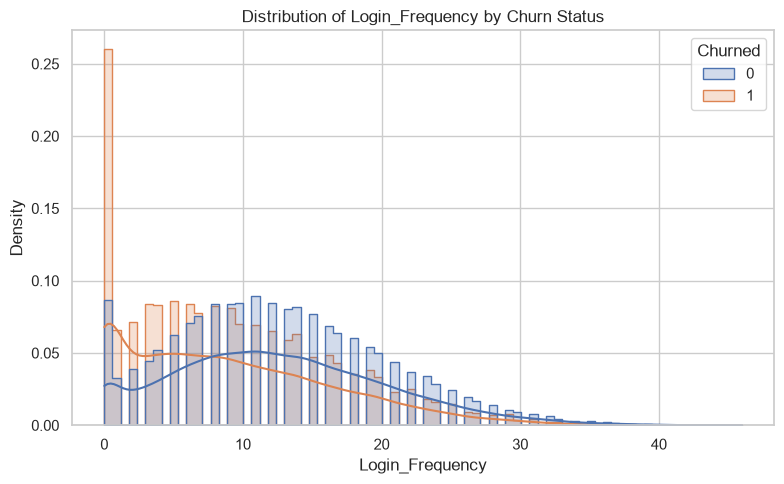

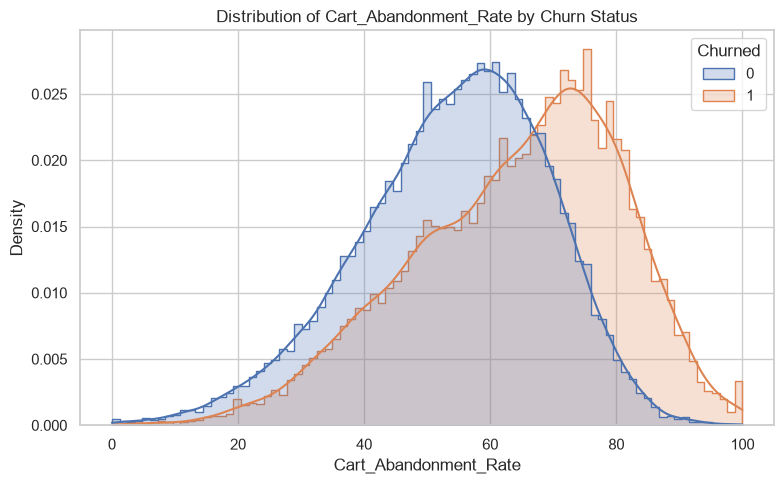

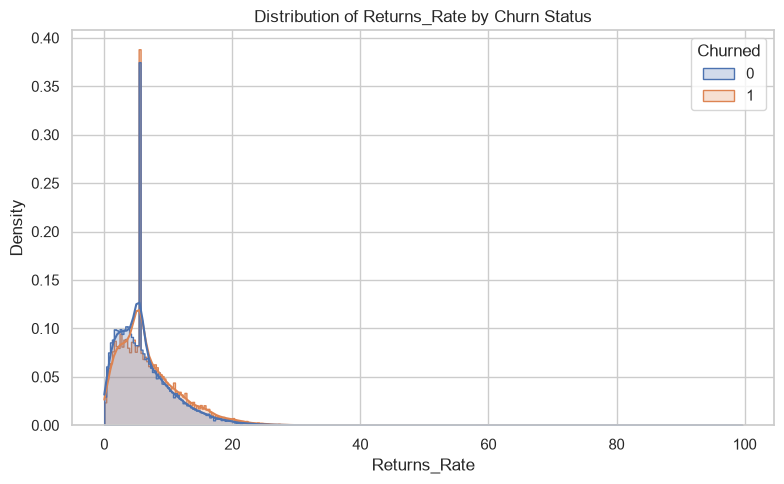

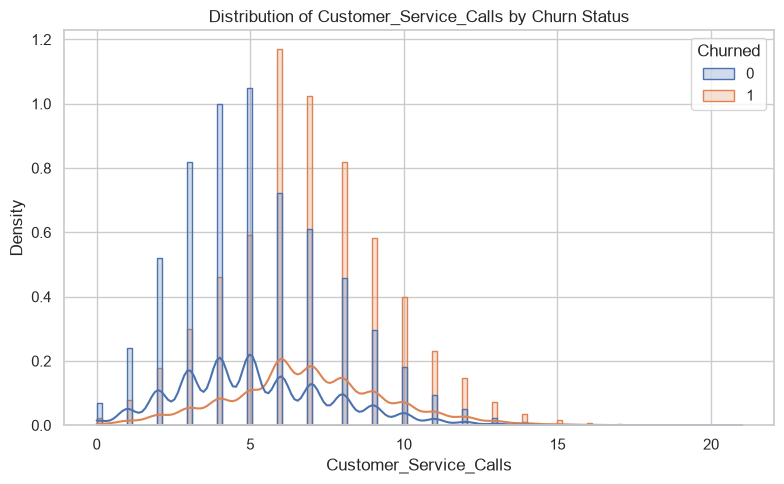

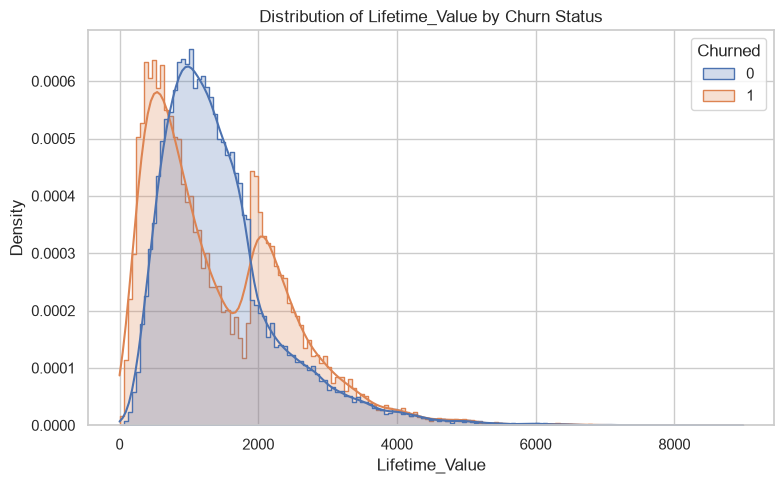

In [14]:
# ============================================================
# DISTRIBUTION VISUALIZATION
# ============================================================

distribution_features = [
    "Days_Since_Last_Purchase",
    "Login_Frequency",
    "Cart_Abandonment_Rate",
    "Returns_Rate",
    "Customer_Service_Calls",
    "Lifetime_Value"
]

distribution_features = [
    col for col in distribution_features
    if col in df.columns
]

for col in distribution_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        hue=TARGET,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"Distribution of {col} by Churn Status")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

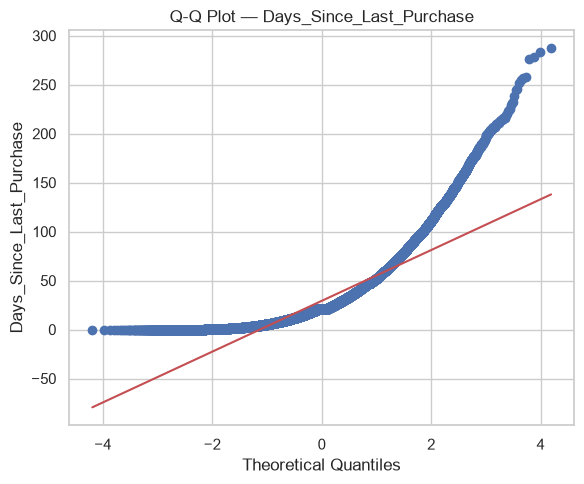

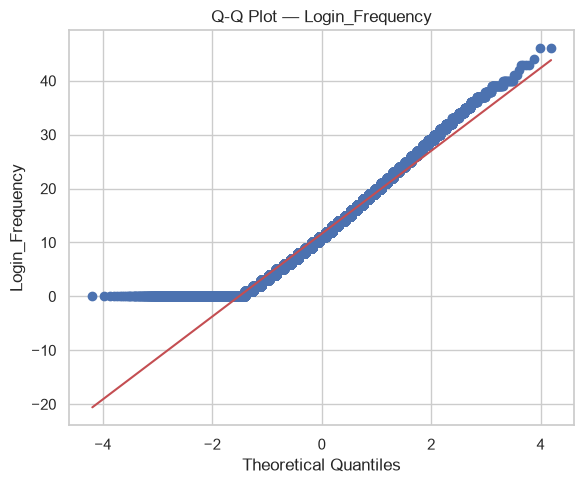

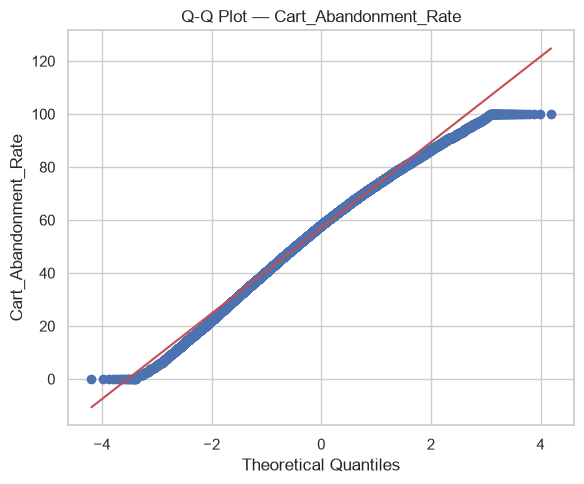

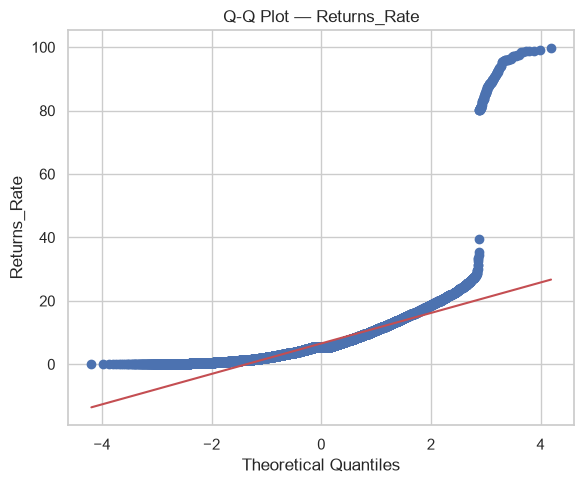

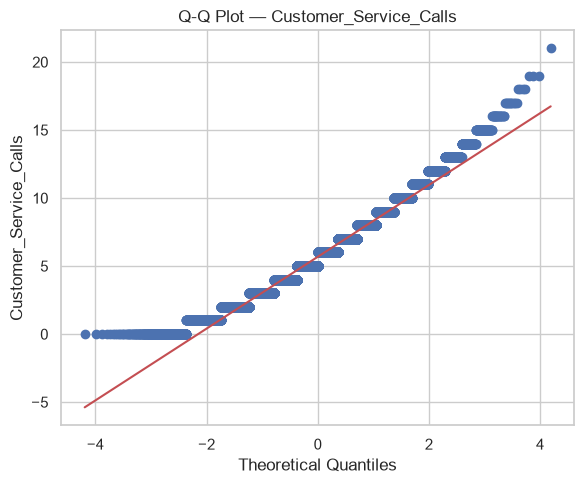

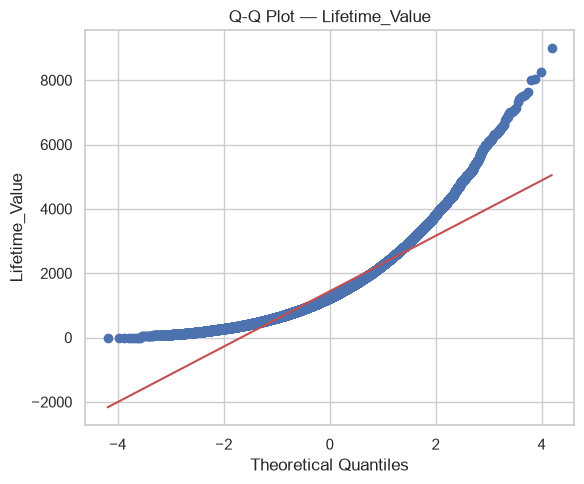

In [17]:
# ============================================================
# Q-Q PLOTS
# ============================================================

for col in distribution_features:
    values = df[col].dropna()

    plt.figure(figsize=(6, 5))

    stats.probplot(
        values,
        dist="norm",
        plot=plt
    )

    plt.xlabel("Theoretical Quantiles")
    plt.ylabel(f"{col}")

    plt.title(f"Q-Q Plot — {col}")
    plt.tight_layout()
    plt.show()

## 7. Numerical Hypothesis Testing

### Research question

Are numerical characteristics significantly different between Active and Churned customers?

### Hypotheses

**H0:** There is no statistically significant difference between Active and Churned customers for the tested numerical variable.

**H1:** There is a statistically significant difference between Active and Churned customers.

### Tests

- Welch's t-test is used as a mean comparison that does not assume equal variances.
- Mann-Whitney U is used as a non-parametric comparison and is robust to non-normal distributions.

Because the dataset is large and behavioral variables can be skewed, the Mann-Whitney result is used as the primary significance result in the final table, while Welch's t-test is retained for comparison.

In [18]:
# ============================================================
# EFFECT SIZE FUNCTIONS
# ============================================================

def cohens_d(group1, group2):
    """
    Cohen's d using pooled standard deviation.
    group1 and group2 should be numeric arrays/Series.
    """
    group1 = pd.Series(group1).dropna()
    group2 = pd.Series(group2).dropna()

    n1, n2 = len(group1), len(group2)

    if n1 < 2 or n2 < 2:
        return np.nan

    s1 = group1.std(ddof=1)
    s2 = group2.std(ddof=1)

    pooled_sd = np.sqrt(
        (
            (n1 - 1) * s1**2
            + (n2 - 1) * s2**2
        )
        / (n1 + n2 - 2)
    )

    if pooled_sd == 0:
        return np.nan

    return (group1.mean() - group2.mean()) / pooled_sd


def rank_biserial_from_u(u_stat, n1, n2):
    """
    Rank-biserial correlation based on the Mann-Whitney U statistic.
    The result is oriented as group1 vs group2.
    """
    if n1 == 0 or n2 == 0:
        return np.nan

    return (2 * u_stat) / (n1 * n2) - 1


def interpret_cohens_d(d):
    if pd.isna(d):
        return "Not available"

    value = abs(d)

    if value < 0.2:
        return "Negligible / Very Small"
    elif value < 0.5:
        return "Small"
    elif value < 0.8:
        return "Medium"
    else:
        return "Large"


def interpret_rank_biserial(r):
    if pd.isna(r):
        return "Not available"

    value = abs(r)

    if value < 0.1:
        return "Very Small"
    elif value < 0.3:
        return "Small"
    elif value < 0.5:
        return "Medium"
    else:
        return "Large"

In [19]:
# ============================================================
# NUMERICAL TESTS
# ============================================================

numerical_results = []

for col in numerical_features:

    active = df.loc[df[TARGET] == 0, col].dropna()
    churned = df.loc[df[TARGET] == 1, col].dropna()

    if len(active) == 0 or len(churned) == 0:
        continue

    # Welch's t-test
    t_stat, t_pvalue = ttest_ind(
        active,
        churned,
        equal_var=False
    )

    # Mann-Whitney U
    u_stat, u_pvalue = mannwhitneyu(
        active,
        churned,
        alternative="two-sided"
    )

    # Effect sizes
    d = cohens_d(churned, active)
    rank_biserial = rank_biserial_from_u(
        u_stat,
        len(churned),
        len(active)
    )

    numerical_results.append({
        "Variable": col,
        "Test_Primary": "Mann-Whitney U",
        "Active_N": len(active),
        "Churned_N": len(churned),
        "Active_Mean": active.mean(),
        "Churned_Mean": churned.mean(),
        "Active_Median": active.median(),
        "Churned_Median": churned.median(),
        "Mean_Difference": churned.mean() - active.mean(),
        "Welch_t_Statistic": t_stat,
        "Welch_P_Value": t_pvalue,
        "MannWhitney_U": u_stat,
        "MannWhitney_P_Value": u_pvalue,
        "Cohens_d": d,
        "Cohens_d_Interpretation": interpret_cohens_d(d),
        "Rank_Biserial_Correlation": rank_biserial,
        "Rank_Biserial_Interpretation": interpret_rank_biserial(rank_biserial)
    })

numerical_results = pd.DataFrame(numerical_results)

display(numerical_results)

,Variable,Test_Primary,Active_N,Churned_N,Active_Mean,Churned_Mean,Active_Median,Churned_Median,Mean_Difference,Welch_t_Statistic,Welch_P_Value,MannWhitney_U,MannWhitney_P_Value,Cohens_d,Cohens_d_Interpretation,Rank_Biserial_Correlation,Rank_Biserial_Interpretation
0,Age,Mann-Whitney U,35550,14450,38.5002,35.9923,38.0000,36.0000,-2.5079,21.9661,0.0000,289184361.0000,0.0000,-0.2260,Small,0.1259,Small
1,Membership_Years,Mann-Whitney U,35550,14450,2.9848,2.9820,2.5000,2.5000,-0.0028,0.1399,0.8888,256472038.0000,0.7968,-0.0014,Negligible / Very Small,-0.0015,Very Small
2,Login_Frequency,Mann-Whitney U,35550,14450,12.6424,9.1208,12.0000,8.0000,-3.5216,47.0717,0.0000,326612475.5000,0.0000,-0.4606,Small,0.2716,Small
3,Session_Duration_Avg,Mann-Whitney U,35550,14450,29.0713,23.9880,27.4000,23.6000,-5.0833,49.8305,0.0000,328757165.5000,0.0000,-0.4964,Small,0.2800,Small
4,Pages_Per_Session,Mann-Whitney U,35550,14450,9.2425,7.4262,8.7000,7.2000,-1.8163,51.0637,0.0000,331369608.5000,0.0000,-0.5087,Medium,0.2901,Small
5,Cart_Abandonment_Rate,Mann-Whitney U,35550,14450,54.1554,64.1471,55.5000,66.6000,9.9917,-62.1767,0.0000,165419115.5000,0.0000,0.6421,Medium,-0.3560,Medium
6,Wishlist_Items,Mann-Whitney U,35550,14450,4.6444,3.3645,4.0000,3.0000,-1.2799,43.9790,0.0000,325933524.5000,0.0000,-0.4259,Small,0.2690,Small
7,Total_Purchases,Mann-Whitney U,35550,14450,13.8440,11.3600,13.0000,10.0000,-2.4840,36.1914,0.0000,318494836.5000,0.0000,-0.3598,Small,0.2400,Small
8,Average_Order_Value,Mann-Whitney U,35550,14450,118.3839,134.7625,108.9350,124.3950,16.3786,-9.1429,0.0000,207205180.0000,0.0000,0.0934,Negligible / Very Small,-0.1933,Small
9,Days_Since_Last_Purchase,Mann-Whitney U,35550,14450,26.5413,35.9669,21.0000,24.0000,9.4255,-29.7820,0.0000,214430640.5000,0.0000,0.3302,Small,-0.1651,Small


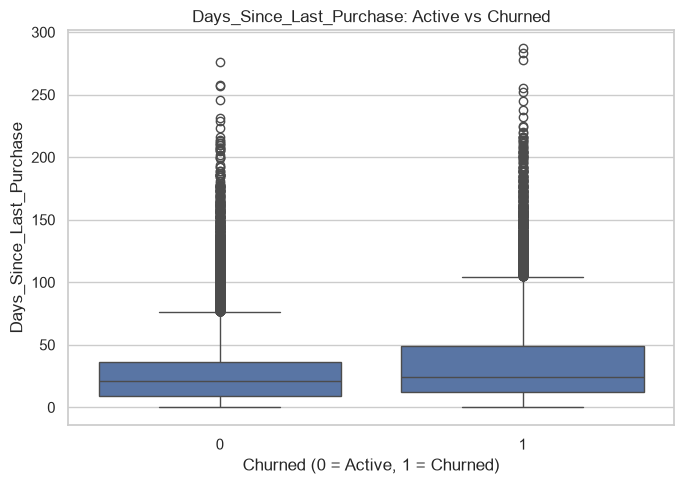

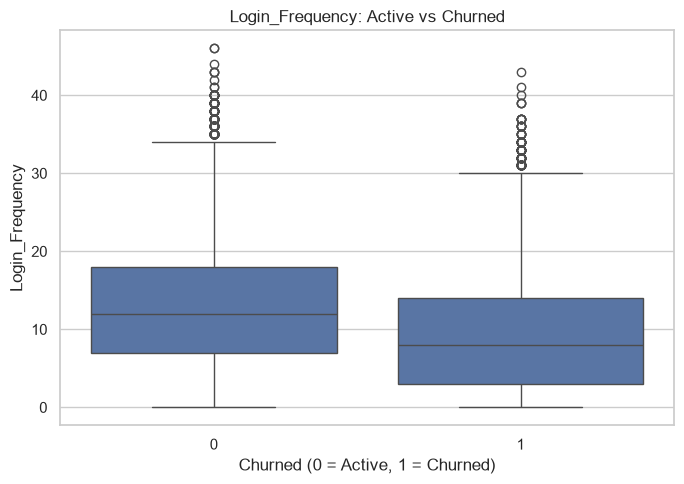

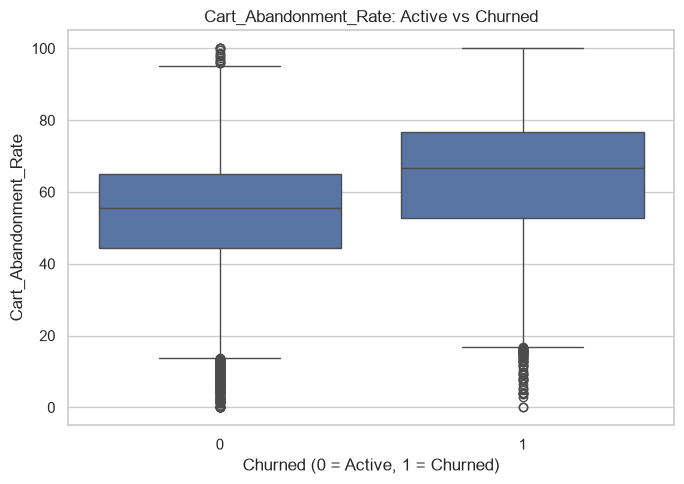

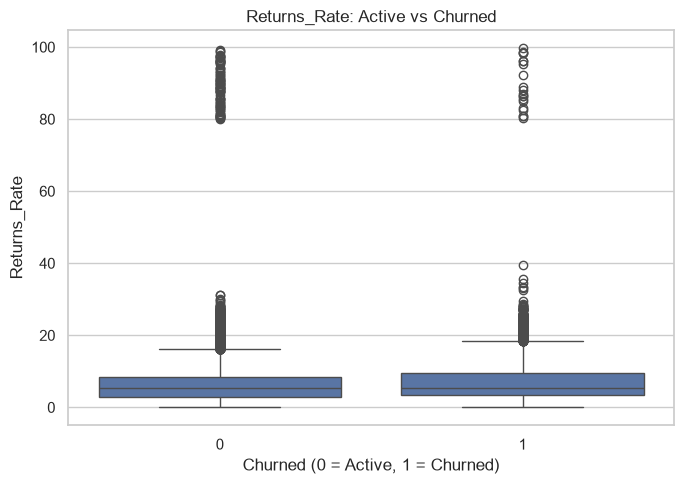

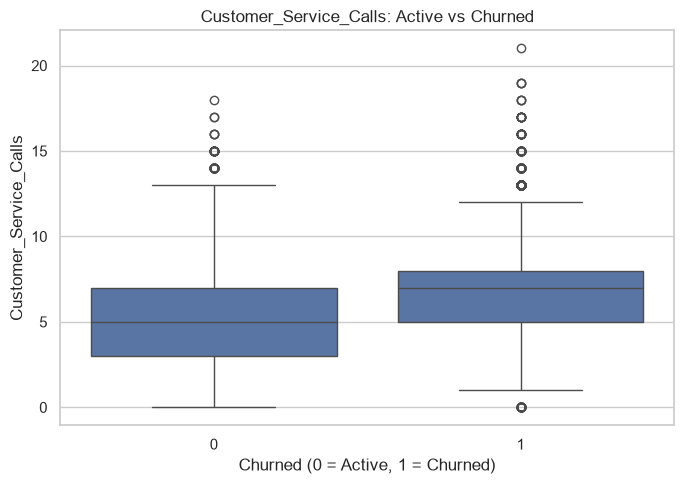

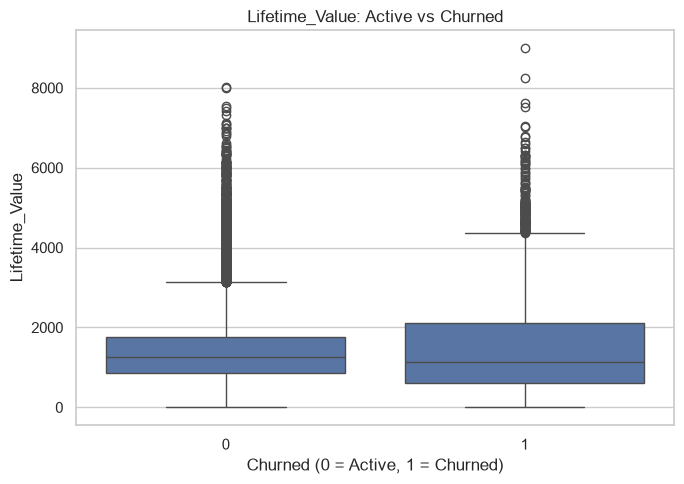

In [26]:
# ============================================================
# BOXPLOTS FOR KEY NUMERICAL FEATURES
# ============================================================

for col in distribution_features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x=TARGET,
        y=col
    )

    plt.title(f"{col}: Active vs Churned")
    plt.xlabel("Churned (0 = Active, 1 = Churned)")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 8. Categorical Hypothesis Testing

### Research question

Are categorical variables associated with customer churn?

### Hypotheses

**H0:** The categorical variable and `Churned` are independent.

**H1:** The categorical variable and `Churned` are associated.

### Primary test

Chi-square test of independence.

### Assumption check

The expected frequencies are inspected. If a 2×2 contingency table has an expected frequency below 5, Fisher's Exact Test is considered instead.

In [27]:
# ============================================================
# CHI-SQUARE / FISHER'S EXACT TEST
# ============================================================

def cramers_v_from_table(contingency_table, chi2_stat):
    n = contingency_table.to_numpy().sum()

    rows, cols = contingency_table.shape
    denominator_dimension = min(rows - 1, cols - 1)

    if n == 0 or denominator_dimension <= 0:
        return np.nan

    return np.sqrt(
        chi2_stat / (n * denominator_dimension)
    )


def interpret_cramers_v(v):
    if pd.isna(v):
        return "Not available"

    if v < 0.1:
        return "Very Weak"
    elif v < 0.3:
        return "Weak"
    elif v < 0.5:
        return "Moderate"
    else:
        return "Strong"


categorical_results = []
contingency_tables = {}
expected_tables = {}

for col in categorical_features:

    # Exclude missing categories from the test itself.
    test_df = df[[col, TARGET]].dropna()

    contingency = pd.crosstab(
        test_df[col],
        test_df[TARGET]
    )

    contingency_tables[col] = contingency

    if contingency.empty:
        continue

    chi2_stat, chi_pvalue, dof, expected = chi2_contingency(
        contingency
    )

    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )

    expected_tables[col] = expected_df

    min_expected = expected.min()

    test_used = "Chi-square"
    statistic = chi2_stat
    p_value = chi_pvalue

    # Fisher's exact test only applies to 2x2 tables.
    if contingency.shape == (2, 2) and min_expected < 5:
        odds_ratio, fisher_pvalue = fisher_exact(contingency)

        test_used = "Fisher's Exact"
        statistic = odds_ratio
        p_value = fisher_pvalue

    cramers_v = cramers_v_from_table(
        contingency,
        chi2_stat
    )

    categorical_results.append({
        "Variable": col,
        "Test": test_used,
        "Statistic": statistic,
        "Chi2_Statistic": chi2_stat,
        "Degrees_of_Freedom": dof,
        "P_Value": p_value,
        "Minimum_Expected_Frequency": min_expected,
        "Cramers_V": cramers_v,
        "Association_Strength": interpret_cramers_v(cramers_v),
        "Categories": contingency.shape[0]
    })

categorical_results = pd.DataFrame(categorical_results)

display(categorical_results)

,Variable,Test,Statistic,Chi2_Statistic,Degrees_of_Freedom,P_Value,Minimum_Expected_Frequency,Cramers_V,Association_Strength,Categories
0,Gender,Chi-square,2.9639,2.9639,2,0.2272,270.7930,0.0077,Very Weak,3
1,Country,Chi-square,9.4396,9.4396,7,0.2226,736.3720,0.0137,Very Weak,8
2,Signup_Quarter,Chi-square,9.1448,9.1448,3,0.0274,3598.9170,0.0135,Very Weak,4


In [28]:
# ============================================================
# DISPLAY CONTINGENCY TABLES
# ============================================================

for col, table in contingency_tables.items():

    print("=" * 80)
    print(f"{col} × {TARGET}")
    print("=" * 80)

    display(table)

Gender × Churned


Churned,0,1
Gender,,
Female,17839,7277
Male,17067,6880
Other,644,293


Country × Churned


Churned,0,1
Country,,
Australia,2847,1214
Canada,4255,1768
France,2918,1095
Germany,3505,1420
India,2493,1019
Japan,1839,709
UK,5365,2169
USA,12328,5056


Signup_Quarter × Churned


Churned,0,1
Signup_Quarter,,
Q1,8802,3651
Q2,8806,3715
Q3,8988,3570
Q4,8954,3514


In [29]:
# ============================================================
# DISPLAY EXPECTED FREQUENCIES
# ============================================================

for col, table in expected_tables.items():

    print("=" * 80)
    print(f"Expected frequencies — {col}")
    print("=" * 80)

    display(table)

Expected frequencies — Gender


Churned,0,1
Gender,,
Female,17857.4760,7258.5240
Male,17026.3170,6920.6830
Other,666.2070,270.7930


Expected frequencies — Country


Churned,0,1
Country,,
Australia,2887.3710,1173.6290
Canada,4282.3530,1740.6470
France,2853.2430,1159.7570
Germany,3501.6750,1423.3250
India,2497.0320,1014.9680
Japan,1811.6280,736.3720
UK,5356.6740,2177.3260
USA,12360.0240,5023.9760


Expected frequencies — Signup_Quarter


Churned,0,1
Signup_Quarter,,
Q1,8854.0830,3598.9170
Q2,8902.4310,3618.5690
Q3,8928.7380,3629.2620
Q4,8864.7480,3603.2520


## 9. Churn Rate by Category

Statistical significance tells us whether an association is detectable.

For business interpretation, we also calculate:

- Total customers
- Churned customers
- Active customers
- Churn rate

This makes categorical results easier to interpret from a business perspective.

In [30]:
# ============================================================
# CHURN RATE FUNCTION
# ============================================================

def churn_rate_by_category(data, column):
    result = (
        data.groupby(column, dropna=False)[TARGET]
            .agg(
                Total_Customers="count",
                Churned_Customers="sum"
            )
            .reset_index()
    )

    result["Active_Customers"] = (
        result["Total_Customers"]
        - result["Churned_Customers"]
    )

    result["Churn_Rate"] = (
        result["Churned_Customers"]
        / result["Total_Customers"]
        * 100
    )

    return result.sort_values(
        "Churn_Rate",
        ascending=False
    )


category_churn_tables = {}

for col in categorical_features:

    result = churn_rate_by_category(df, col)

    category_churn_tables[col] = result

    print("=" * 80)
    print(f"CHURN RATE BY {col.upper()}")
    print("=" * 80)

    display(result)

CHURN RATE BY GENDER


,Gender,Total_Customers,Churned_Customers,Active_Customers,Churn_Rate
2,Other,937,293,644,31.2700
0,Female,25116,7277,17839,28.9736
1,Male,23947,6880,17067,28.7301


CHURN RATE BY COUNTRY


,Country,Total_Customers,Churned_Customers,Active_Customers,Churn_Rate
0,Australia,4061,1214,2847,29.8941
1,Canada,6023,1768,4255,29.3541
7,USA,17384,5056,12328,29.0842
4,India,3512,1019,2493,29.0148
3,Germany,4925,1420,3505,28.8325
6,UK,7534,2169,5365,28.7895
5,Japan,2548,709,1839,27.8257
2,France,4013,1095,2918,27.2863


CHURN RATE BY SIGNUP_QUARTER


,Signup_Quarter,Total_Customers,Churned_Customers,Active_Customers,Churn_Rate
1,Q2,12521,3715,8806,29.6702
0,Q1,12453,3651,8802,29.3182
2,Q3,12558,3570,8988,28.4281
3,Q4,12468,3514,8954,28.1842


## 10. Optional Age and Membership Groups

If `Age_Group` and `Membership_Group` were already created in the EDA / cleaned dataset, they are analyzed here as categorical variables.

If they are not present, this notebook does not silently recreate them, because the statistical-analysis notebook is intended to use the cleaned input from the previous stage.

In [51]:
# ============================================================
# AGE / MEMBERSHIP GROUP OUTPUT IF AVAILABLE
# ============================================================
###
bins = [0, 25, 35, 45, 55, float("inf")]

labels = [
    "<=25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)
###
max_year = int(np.ceil(df["Membership_Years"].max()))

bins = np.arange(0, max_year + 2, 1)
labels = [f"{i}-{i+1} năm" for i in range(max_year + 1)]

df["Membership_Group"] = pd.cut(
    df["Membership_Years"],
    bins=bins,
    labels=labels,
    right=False
)

for col in ["Age_Group", "Membership_Group"]:
    if col in df.columns:
        print("=" * 80)
        print(f"{col}")
        print("=" * 80)
        display(churn_rate_by_category(df, col))

Age_Group


,Age_Group,Total_Customers,Churned_Customers,Active_Customers,Churn_Rate
0,<=25,7511,3417,4094,45.4933
4,56+,3204,850,2354,26.5293
1,26-35,13049,3453,9596,26.4618
3,46-55,8834,2308,6526,26.1263
2,36-45,17402,4422,12980,25.4109


Membership_Group


,Membership_Group,Total_Customers,Churned_Customers,Active_Customers,Churn_Rate
9,9-10 năm,392,116,276,29.5918
2,2-3 năm,10594,3120,7474,29.4506
3,3-4 năm,7647,2244,5403,29.3448
7,7-8 năm,1161,340,821,29.2851
5,5-6 năm,3224,938,2286,29.0943
4,4-5 năm,5141,1477,3664,28.7298
0,0-1 năm,6767,1941,4826,28.6833
1,1-2 năm,11907,3391,8516,28.4790
10,10-11 năm,523,146,377,27.9159
6,6-7 năm,1978,552,1426,27.9070


## 11. Multiple Testing Correction

Multiple hypothesis tests increase the probability of false-positive findings.

The Benjamini-Hochberg False Discovery Rate (FDR) procedure is applied separately to:

- Numerical tests
- Categorical tests

The final significance decision uses:

```text
Adjusted P-value < 0.05
```

In [32]:
# ============================================================
# BENJAMINI-HOCHBERG — NUMERICAL
# ============================================================

if not numerical_results.empty:

    reject, adjusted_p, _, _ = multipletests(
        numerical_results["MannWhitney_P_Value"],
        alpha=ALPHA,
        method="fdr_bh"
    )

    numerical_results["Adjusted_P_Value"] = adjusted_p
    numerical_results["Significant"] = reject

    numerical_results["Statistical_Conclusion"] = np.where(
        numerical_results["Significant"],
        "Significant difference between Active and Churned",
        "No statistically significant difference"
    )

display(
    numerical_results.sort_values(
        "Adjusted_P_Value"
    )
)

,Variable,Test_Primary,Active_N,Churned_N,Active_Mean,Churned_Mean,Active_Median,Churned_Median,Mean_Difference,Welch_t_Statistic,Welch_P_Value,MannWhitney_U,MannWhitney_P_Value,Cohens_d,Cohens_d_Interpretation,Rank_Biserial_Correlation,Rank_Biserial_Interpretation,Adjusted_P_Value,Significant,Statistical_Conclusion
3,Session_Duration_Avg,Mann-Whitney U,35550,14450,29.0713,23.9880,27.4000,23.6000,-5.0833,49.8305,0.0000,328757165.5000,0.0000,-0.4964,Small,0.2800,Small,0.0000,True,Significant difference between Active and Churned
2,Login_Frequency,Mann-Whitney U,35550,14450,12.6424,9.1208,12.0000,8.0000,-3.5216,47.0717,0.0000,326612475.5000,0.0000,-0.4606,Small,0.2716,Small,0.0000,True,Significant difference between Active and Churned
5,Cart_Abandonment_Rate,Mann-Whitney U,35550,14450,54.1554,64.1471,55.5000,66.6000,9.9917,-62.1767,0.0000,165419115.5000,0.0000,0.6421,Medium,-0.3560,Medium,0.0000,True,Significant difference between Active and Churned
4,Pages_Per_Session,Mann-Whitney U,35550,14450,9.2425,7.4262,8.7000,7.2000,-1.8163,51.0637,0.0000,331369608.5000,0.0000,-0.5087,Medium,0.2901,Small,0.0000,True,Significant difference between Active and Churned
6,Wishlist_Items,Mann-Whitney U,35550,14450,4.6444,3.3645,4.0000,3.0000,-1.2799,43.9790,0.0000,325933524.5000,0.0000,-0.4259,Small,0.2690,Small,0.0000,True,Significant difference between Active and Churned
7,Total_Purchases,Mann-Whitney U,35550,14450,13.8440,11.3600,13.0000,10.0000,-2.4840,36.1914,0.0000,318494836.5000,0.0000,-0.3598,Small,0.2400,Small,0.0000,True,Significant difference between Active and Churned
14,Product_Reviews_Written,Mann-Whitney U,35550,14450,3.0446,2.1761,3.0000,2.0000,-0.8684,40.7900,0.0000,321675270.0000,0.0000,-0.3909,Small,0.2524,Small,0.0000,True,Significant difference between Active and Churned
15,Social_Media_Engagement_Score,Mann-Whitney U,35550,14450,31.3664,23.7065,27.6000,23.8000,-7.6599,41.4017,0.0000,317508103.5000,0.0000,-0.4033,Small,0.2362,Small,0.0000,True,Significant difference between Active and Churned
13,Customer_Service_Calls,Mann-Whitney U,35550,14450,5.1849,6.8965,5.0000,7.0000,1.7116,-67.0262,0.0000,159747427.0000,0.0000,0.6694,Medium,-0.3780,Medium,0.0000,True,Significant difference between Active and Churned
12,Email_Open_Rate,Mann-Whitney U,35550,14450,22.7903,16.1644,21.1000,14.9000,-6.6259,49.7366,0.0000,330636760.0000,0.0000,-0.4886,Small,0.2873,Small,0.0000,True,Significant difference between Active and Churned


In [33]:
# ============================================================
# BENJAMINI-HOCHBERG — CATEGORICAL
# ============================================================

if not categorical_results.empty:

    reject, adjusted_p, _, _ = multipletests(
        categorical_results["P_Value"],
        alpha=ALPHA,
        method="fdr_bh"
    )

    categorical_results["Adjusted_P_Value"] = adjusted_p
    categorical_results["Significant"] = reject

    categorical_results["Statistical_Conclusion"] = np.where(
        categorical_results["Significant"],
        "Significant association with Churn",
        "No statistically significant association"
    )

display(
    categorical_results.sort_values(
        "Adjusted_P_Value"
    )
)

,Variable,Test,Statistic,Chi2_Statistic,Degrees_of_Freedom,P_Value,Minimum_Expected_Frequency,Cramers_V,Association_Strength,Categories,Adjusted_P_Value,Significant,Statistical_Conclusion
2,Signup_Quarter,Chi-square,9.1448,9.1448,3,0.0274,3598.9170,0.0135,Very Weak,4,0.0823,False,No statistically significant association
0,Gender,Chi-square,2.9639,2.9639,2,0.2272,270.7930,0.0077,Very Weak,3,0.2272,False,No statistically significant association
1,Country,Chi-square,9.4396,9.4396,7,0.2226,736.3720,0.0137,Very Weak,8,0.2272,False,No statistically significant association


## 12. Final Numerical Results

The primary numerical result is based on the Mann-Whitney U test after Benjamini-Hochberg correction.

Effect sizes are shown alongside p-values so that statistical significance is not interpreted without considering the magnitude of the difference.

In [34]:
# ============================================================
# NUMERICAL FINAL TABLE
# ============================================================

numerical_final = numerical_results[
    [
        "Variable",
        "Test_Primary",
        "Active_N",
        "Churned_N",
        "Active_Mean",
        "Churned_Mean",
        "Active_Median",
        "Churned_Median",
        "Mean_Difference",
        "MannWhitney_U",
        "MannWhitney_P_Value",
        "Adjusted_P_Value",
        "Cohens_d",
        "Cohens_d_Interpretation",
        "Rank_Biserial_Correlation",
        "Rank_Biserial_Interpretation",
        "Significant",
        "Statistical_Conclusion"
    ]
].sort_values("Adjusted_P_Value")

display(numerical_final)

,Variable,Test_Primary,Active_N,Churned_N,Active_Mean,Churned_Mean,Active_Median,Churned_Median,Mean_Difference,MannWhitney_U,MannWhitney_P_Value,Adjusted_P_Value,Cohens_d,Cohens_d_Interpretation,Rank_Biserial_Correlation,Rank_Biserial_Interpretation,Significant,Statistical_Conclusion
3,Session_Duration_Avg,Mann-Whitney U,35550,14450,29.0713,23.9880,27.4000,23.6000,-5.0833,328757165.5000,0.0000,0.0000,-0.4964,Small,0.2800,Small,True,Significant difference between Active and Churned
2,Login_Frequency,Mann-Whitney U,35550,14450,12.6424,9.1208,12.0000,8.0000,-3.5216,326612475.5000,0.0000,0.0000,-0.4606,Small,0.2716,Small,True,Significant difference between Active and Churned
5,Cart_Abandonment_Rate,Mann-Whitney U,35550,14450,54.1554,64.1471,55.5000,66.6000,9.9917,165419115.5000,0.0000,0.0000,0.6421,Medium,-0.3560,Medium,True,Significant difference between Active and Churned
4,Pages_Per_Session,Mann-Whitney U,35550,14450,9.2425,7.4262,8.7000,7.2000,-1.8163,331369608.5000,0.0000,0.0000,-0.5087,Medium,0.2901,Small,True,Significant difference between Active and Churned
6,Wishlist_Items,Mann-Whitney U,35550,14450,4.6444,3.3645,4.0000,3.0000,-1.2799,325933524.5000,0.0000,0.0000,-0.4259,Small,0.2690,Small,True,Significant difference between Active and Churned
7,Total_Purchases,Mann-Whitney U,35550,14450,13.8440,11.3600,13.0000,10.0000,-2.4840,318494836.5000,0.0000,0.0000,-0.3598,Small,0.2400,Small,True,Significant difference between Active and Churned
14,Product_Reviews_Written,Mann-Whitney U,35550,14450,3.0446,2.1761,3.0000,2.0000,-0.8684,321675270.0000,0.0000,0.0000,-0.3909,Small,0.2524,Small,True,Significant difference between Active and Churned
15,Social_Media_Engagement_Score,Mann-Whitney U,35550,14450,31.3664,23.7065,27.6000,23.8000,-7.6599,317508103.5000,0.0000,0.0000,-0.4033,Small,0.2362,Small,True,Significant difference between Active and Churned
13,Customer_Service_Calls,Mann-Whitney U,35550,14450,5.1849,6.8965,5.0000,7.0000,1.7116,159747427.0000,0.0000,0.0000,0.6694,Medium,-0.3780,Medium,True,Significant difference between Active and Churned
12,Email_Open_Rate,Mann-Whitney U,35550,14450,22.7903,16.1644,21.1000,14.9000,-6.6259,330636760.0000,0.0000,0.0000,-0.4886,Small,0.2873,Small,True,Significant difference between Active and Churned


## 13. Final Categorical Results

In [35]:
# ============================================================
# CATEGORICAL FINAL TABLE
# ============================================================

categorical_final = categorical_results[
    [
        "Variable",
        "Test",
        "Statistic",
        "Chi2_Statistic",
        "Degrees_of_Freedom",
        "P_Value",
        "Adjusted_P_Value",
        "Minimum_Expected_Frequency",
        "Cramers_V",
        "Association_Strength",
        "Significant",
        "Statistical_Conclusion"
    ]
].sort_values("Adjusted_P_Value")

display(categorical_final)

,Variable,Test,Statistic,Chi2_Statistic,Degrees_of_Freedom,P_Value,Adjusted_P_Value,Minimum_Expected_Frequency,Cramers_V,Association_Strength,Significant,Statistical_Conclusion
2,Signup_Quarter,Chi-square,9.1448,9.1448,3,0.0274,0.0823,3598.9170,0.0135,Very Weak,False,No statistically significant association
0,Gender,Chi-square,2.9639,2.9639,2,0.2272,0.2272,270.7930,0.0077,Very Weak,False,No statistically significant association
1,Country,Chi-square,9.4396,9.4396,7,0.2226,0.2272,736.3720,0.0137,Very Weak,False,No statistically significant association


## 14. Significant Feature Screening

This is a **statistical screening output**, not the final ML feature list.

A feature with a non-significant univariate test should **not automatically be removed from Machine Learning**. ML may identify nonlinear effects or interactions with other variables.

The screening table is therefore used as supporting evidence for the next Feature Engineering / ML stage.

In [36]:
# ============================================================
# SIGNIFICANT NUMERICAL FEATURES
# ============================================================

significant_numerical = numerical_final[
    numerical_final["Significant"]
].copy()

print("Significant numerical features:")
display(
    significant_numerical[
        [
            "Variable",
            "Adjusted_P_Value",
            "Cohens_d",
            "Cohens_d_Interpretation",
            "Rank_Biserial_Correlation",
            "Rank_Biserial_Interpretation"
        ]
    ]
)

Significant numerical features:


,Variable,Adjusted_P_Value,Cohens_d,Cohens_d_Interpretation,Rank_Biserial_Correlation,Rank_Biserial_Interpretation
3,Session_Duration_Avg,0.0000,-0.4964,Small,0.2800,Small
2,Login_Frequency,0.0000,-0.4606,Small,0.2716,Small
5,Cart_Abandonment_Rate,0.0000,0.6421,Medium,-0.3560,Medium
4,Pages_Per_Session,0.0000,-0.5087,Medium,0.2901,Small
6,Wishlist_Items,0.0000,-0.4259,Small,0.2690,Small
7,Total_Purchases,0.0000,-0.3598,Small,0.2400,Small
14,Product_Reviews_Written,0.0000,-0.3909,Small,0.2524,Small
15,Social_Media_Engagement_Score,0.0000,-0.4033,Small,0.2362,Small
13,Customer_Service_Calls,0.0000,0.6694,Medium,-0.3780,Medium
12,Email_Open_Rate,0.0000,-0.4886,Small,0.2873,Small


In [38]:
# ============================================================
# SIGNIFICANT CATEGORICAL FEATURES
# ============================================================

significant_categorical = categorical_final[
    categorical_final["Significant"]
].copy()

print("Significant categorical features:")
display(
    significant_categorical[
        [
            "Variable",
            "Adjusted_P_Value",
            "Cramers_V",
            "Association_Strength"
        ]
    ]
)

Significant categorical features:


,Variable,Adjusted_P_Value,Cramers_V,Association_Strength


## 15. Correlation with Churn

Correlation is used as a supplementary descriptive measure for numerical variables.

It does not replace hypothesis testing and does not imply causation.

In [39]:
# ============================================================
# CORRELATION WITH CHURN
# ============================================================

correlation_with_churn = (
    df[numerical_features + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

correlation_table = correlation_with_churn.to_frame(
    "Correlation_with_Churn"
)

display(correlation_table)

,Correlation_with_Churn
Customer_Service_Calls,0.2904
Cart_Abandonment_Rate,0.2795
Pages_Per_Session,-0.2247
Session_Duration_Avg,-0.2195
Email_Open_Rate,-0.2162
Mobile_App_Usage,-0.2114
Login_Frequency,-0.2044
Wishlist_Items,-0.1896
Social_Media_Engagement_Score,-0.1798
Product_Reviews_Written,-0.1745


## 16. Visualization of Statistical Findings

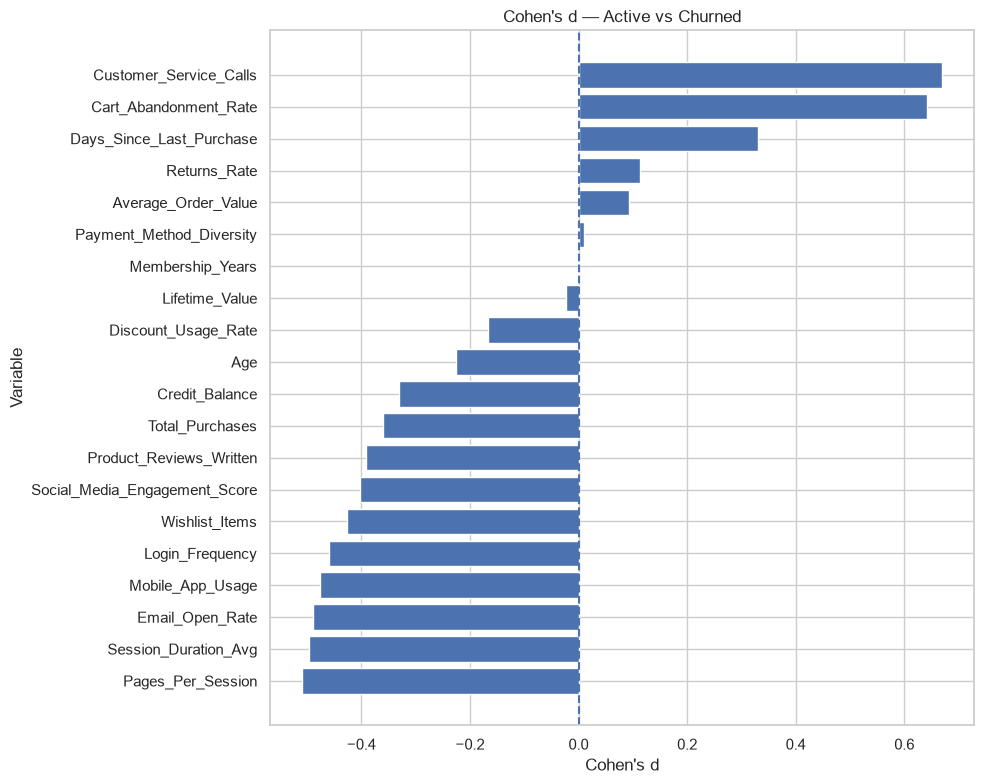

In [40]:
# ============================================================
# EFFECT SIZE — NUMERICAL
# ============================================================

effect_plot = (
    numerical_final[
        ["Variable", "Cohens_d"]
    ]
    .dropna()
    .sort_values("Cohens_d")
)

plt.figure(figsize=(10, 8))

plt.barh(
    effect_plot["Variable"],
    effect_plot["Cohens_d"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Cohen's d — Active vs Churned")
plt.xlabel("Cohen's d")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

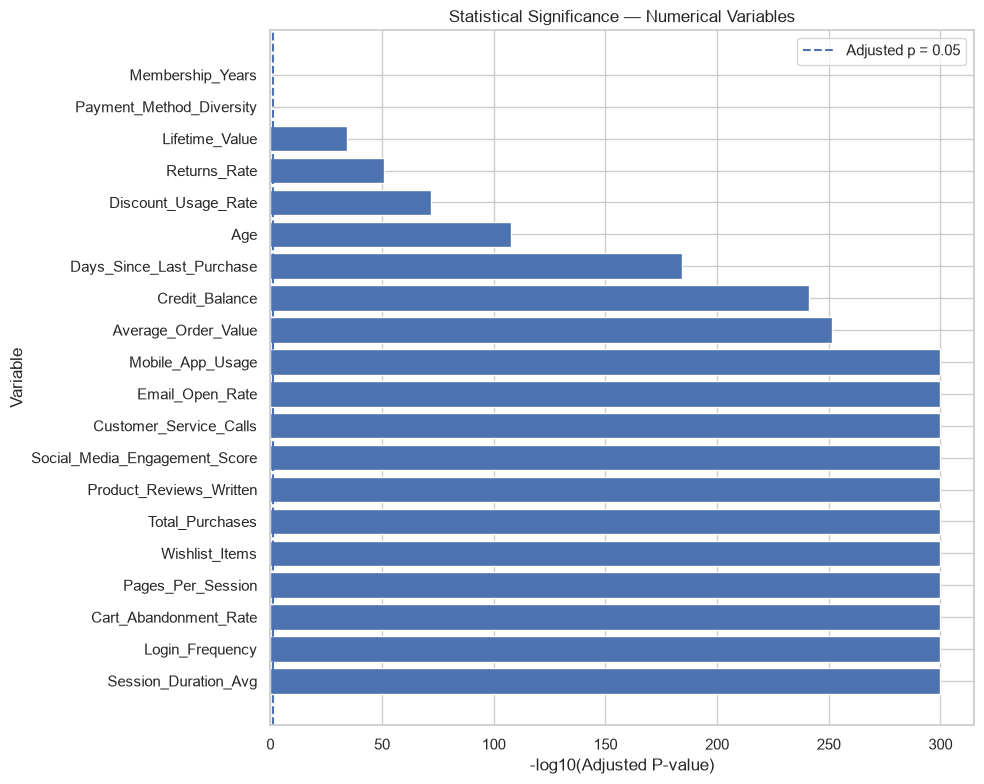

In [41]:
# ============================================================
# ADJUSTED P-VALUE — NUMERICAL
# ============================================================

pvalue_plot = (
    numerical_final[
        ["Variable", "Adjusted_P_Value"]
    ]
    .dropna()
    .sort_values("Adjusted_P_Value")
)

plot_values = pvalue_plot["Adjusted_P_Value"].clip(
    lower=1e-300
)

plt.figure(figsize=(10, 8))

plt.barh(
    pvalue_plot["Variable"],
    -np.log10(plot_values)
)

plt.axvline(
    -np.log10(ALPHA),
    linestyle="--",
    label="Adjusted p = 0.05"
)

plt.title("Statistical Significance — Numerical Variables")
plt.xlabel("-log10(Adjusted P-value)")
plt.ylabel("Variable")
plt.legend()

plt.tight_layout()
plt.show()

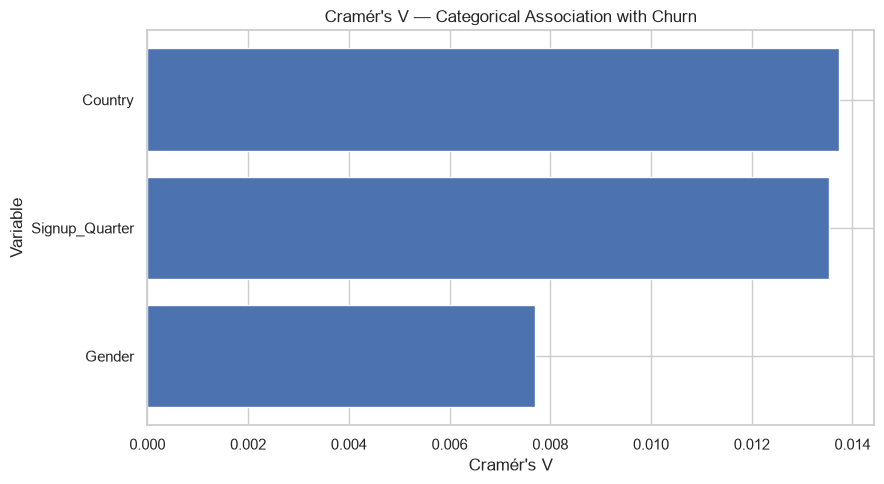

In [42]:
# ============================================================
# CRAMER'S V — CATEGORICAL
# ============================================================

if not categorical_final.empty:

    cramers_plot = (
        categorical_final[
            ["Variable", "Cramers_V"]
        ]
        .dropna()
        .sort_values("Cramers_V")
    )

    plt.figure(figsize=(9, 5))

    plt.barh(
        cramers_plot["Variable"],
        cramers_plot["Cramers_V"]
    )

    plt.title("Cramér's V — Categorical Association with Churn")
    plt.xlabel("Cramér's V")
    plt.ylabel("Variable")

    plt.tight_layout()
    plt.show()

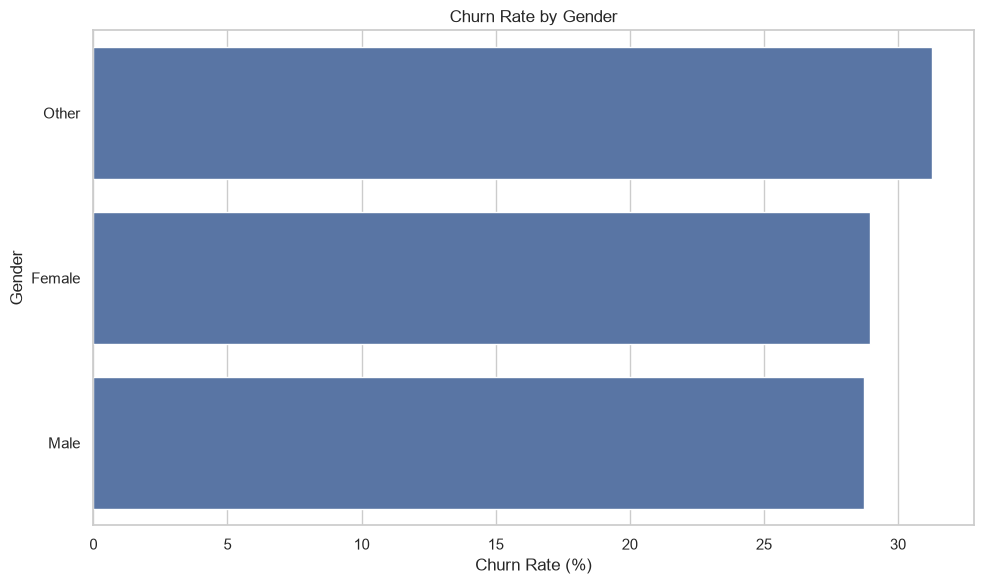

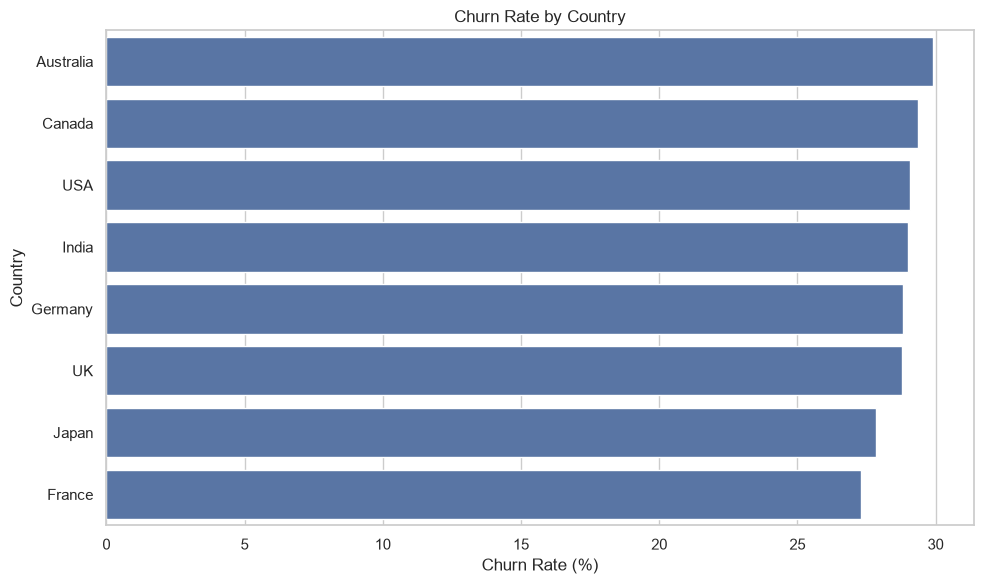

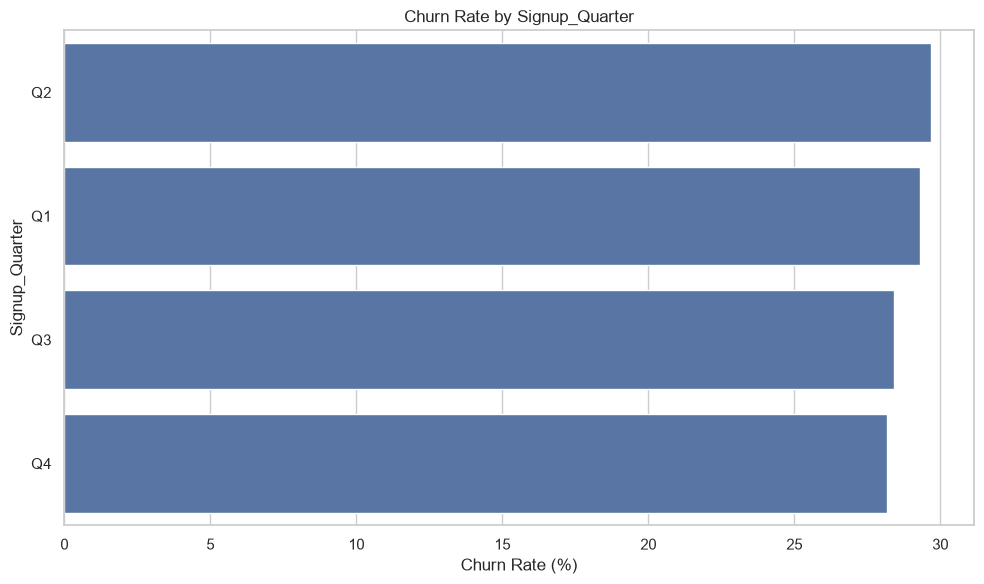

In [43]:
# ============================================================
# CHURN RATE VISUALIZATION FOR CATEGORICAL FEATURES
# ============================================================

for col in categorical_features:

    result = category_churn_tables[col]

    # Avoid overly large plots for high-cardinality variables such as City.
    plot_result = result.copy()

    if len(plot_result) > 15:
        plot_result = plot_result.head(15)

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=plot_result,
        x="Churn_Rate",
        y=col
    )

    plt.title(f"Churn Rate by {col}")
    plt.xlabel("Churn Rate (%)")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 17. Final Statistical Summary

This section answers the statistical-analysis objective in a compact form.

### Interpretation framework

A variable is considered statistically significant when:

```text
Adjusted P-value < 0.05
```

However, effect size must also be considered.

For numerical variables:

- Cohen's d
- Rank-biserial correlation

For categorical variables:

- Cramér's V

The result should be interpreted as an association or group difference, **not a causal relationship**.

In [44]:
# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

num_total = len(numerical_final)
num_significant = int(numerical_final["Significant"].sum()) if num_total else 0

cat_total = len(categorical_final)
cat_significant = int(categorical_final["Significant"].sum()) if cat_total else 0

print("=" * 90)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 90)

print(f"Total customers: {len(df):,}")
print(f"Overall churn rate: {df[TARGET].mean() * 100:.2f}%")

print("\nNumerical analysis:")
print(f"- Variables tested: {num_total}")
print(f"- Significant after FDR correction: {num_significant}")

print("\nCategorical analysis:")
print(f"- Variables tested: {cat_total}")
print(f"- Significant after FDR correction: {cat_significant}")

print("\nTop numerical features by adjusted p-value:")
display(
    numerical_final[
        [
            "Variable",
            "Adjusted_P_Value",
            "Cohens_d",
            "Cohens_d_Interpretation"
        ]
    ].head(10)
)

print("\nCategorical variables associated with churn:")
display(
    categorical_final[
        [
            "Variable",
            "Adjusted_P_Value",
            "Cramers_V",
            "Association_Strength"
        ]
    ]
)

STATISTICAL ANALYSIS SUMMARY
Total customers: 50,000
Overall churn rate: 28.90%

Numerical analysis:
- Variables tested: 20
- Significant after FDR correction: 18

Categorical analysis:
- Variables tested: 3
- Significant after FDR correction: 0

Top numerical features by adjusted p-value:


,Variable,Adjusted_P_Value,Cohens_d,Cohens_d_Interpretation
3,Session_Duration_Avg,0.0000,-0.4964,Small
2,Login_Frequency,0.0000,-0.4606,Small
5,Cart_Abandonment_Rate,0.0000,0.6421,Medium
4,Pages_Per_Session,0.0000,-0.5087,Medium
6,Wishlist_Items,0.0000,-0.4259,Small
7,Total_Purchases,0.0000,-0.3598,Small
14,Product_Reviews_Written,0.0000,-0.3909,Small
15,Social_Media_Engagement_Score,0.0000,-0.4033,Small
13,Customer_Service_Calls,0.0000,0.6694,Medium
12,Email_Open_Rate,0.0000,-0.4886,Small



Categorical variables associated with churn:


,Variable,Adjusted_P_Value,Cramers_V,Association_Strength
2,Signup_Quarter,0.0823,0.0135,Very Weak
0,Gender,0.2272,0.0077,Very Weak
1,Country,0.2272,0.0137,Very Weak


## 18. Business Interpretation

Use the actual numerical outputs above to formulate findings.

The correct language is:

- "is associated with churn"
- "shows a statistically significant difference"
- "churned customers have a higher/lower observed value"
- "the association is weak/moderate/strong based on the effect size"

Avoid causal statements such as:

- "this variable causes churn"
- "increasing this variable will cause customers to churn"

because statistical analysis of this observational dataset does not establish causality.

### Example interpretation template

> `Days_Since_Last_Purchase` shows a statistically significant difference between Active and Churned customers after multiple-testing correction. Churned customers have a higher observed median value, indicating that purchase recency is associated with churn in this dataset.

Replace the example with the actual results produced by the notebook.

## 19. Export Results

The following CSV files are generated for reporting and for use as supporting outputs in the next project stages.

In [45]:
# ============================================================
# EXPORT RESULTS
# ============================================================

# Descriptive statistics
descriptive_statistics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "descriptive_statistics.csv"
    ),
    index=False
)

# Numerical statistical tests
numerical_final.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "numerical_test_results.csv"
    ),
    index=False
)

# Categorical statistical tests
categorical_final.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "categorical_test_results.csv"
    ),
    index=False
)

# Effect sizes
numerical_effect_sizes = numerical_final[
    [
        "Variable",
        "Cohens_d",
        "Cohens_d_Interpretation",
        "Rank_Biserial_Correlation",
        "Rank_Biserial_Interpretation"
    ]
].copy()

categorical_effect_sizes = categorical_final[
    [
        "Variable",
        "Cramers_V",
        "Association_Strength"
    ]
].copy()

numerical_effect_sizes.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "numerical_effect_sizes.csv"
    ),
    index=False
)

categorical_effect_sizes.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "categorical_effect_sizes.csv"
    ),
    index=False
)

# Correlation
correlation_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "correlation_with_churn.csv"
    )
)

# Significant numerical features
significant_numerical[
    [
        "Variable",
        "Adjusted_P_Value",
        "Cohens_d",
        "Cohens_d_Interpretation"
    ]
].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "significant_numerical_features.csv"
    ),
    index=False
)

# Significant categorical features
significant_categorical[
    [
        "Variable",
        "Adjusted_P_Value",
        "Cramers_V",
        "Association_Strength"
    ]
].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "significant_categorical_features.csv"
    ),
    index=False
)

print("All statistical-analysis outputs have been exported.")

All statistical-analysis outputs have been exported.


In [46]:
# ============================================================
# EXPORT CATEGORY CHURN TABLES
# ============================================================

for col, table in category_churn_tables.items():

    safe_name = (
        col
        .lower()
        .replace(" ", "_")
    )

    table.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"churn_rate_by_{safe_name}.csv"
        ),
        index=False
    )

print("Category churn-rate tables exported.")

Category churn-rate tables exported.


In [47]:
# ============================================================
# LIST OUTPUT FILES
# ============================================================

print(f"Output directory: {OUTPUT_DIR}\n")

for filename in sorted(os.listdir(OUTPUT_DIR)):
    print(filename)

Output directory: D:/Desktop/Projects/customer-churn-analytics/reports/statistical_analysis

categorical_effect_sizes.csv
categorical_test_results.csv
churn_rate_by_country.csv
churn_rate_by_gender.csv
churn_rate_by_signup_quarter.csv
correlation_with_churn.csv
descriptive_statistics.csv
numerical_effect_sizes.csv
numerical_test_results.csv
significant_categorical_features.csv
significant_numerical_features.csv


## 20. Final Conclusion

### Statistical Analysis completed

This notebook has:

1. Validated the cleaned dataset and target variable.
2. Compared Active and Churned customers descriptively.
3. Examined distributions and assumptions.
4. Tested numerical variables using Welch's t-test and Mann-Whitney U.
5. Tested categorical variables using Chi-square, with Fisher's Exact Test for eligible 2×2 cases when required.
6. Calculated effect sizes.
7. Applied Benjamini-Hochberg FDR correction.
8. Produced supporting statistical visualizations.
9. Generated final statistical tables and business-oriented churn-rate summaries.
10. Exported results for the next stages.

### Important limitation

Statistical significance does not imply causation.

### Next step

```text
Statistical Analysis
        ↓
Feature Engineering
        ↓
Leakage Check
        ↓
Train / Test Split
        ↓
Preprocessing Pipeline
        ↓
Machine Learning
        ↓
Model Evaluation
        ↓
SHAP
```

The significant-feature tables from this notebook are **supporting evidence**, not an automatic final ML feature-selection rule.